# MIS 584 — TwinBytes: Scalable Retail Demand Forecasting
## Notebook 2: Exploratory Data Analysis (EDA)

**Team:** TwinBytes — Ashleigh McNamara, Purva Pandit  
**Course:** MIS 584: Big Data Technologies  
**Depends on:** Notebook 1 must have been run this session (Spark table `m5_features` must exist)

---

## What this notebook does

This notebook explores the M5 Walmart dataset visually and statistically before any modeling begins. The goal is to understand patterns in the data, validate our feature engineering decisions from Notebook 1, and identify characteristics (like intermittent demand) that will affect our modeling choices in Notebook 3.

---

## Key questions we answer

| Question | Step |
|---|---|
| What does overall sales volume look like over 5 years? | Step 3 |
| Are there weekly or seasonal patterns? | Step 4 |
| Do sales differ significantly across stores and states? | Step 5 |
| Which product categories have intermittent demand? | Step 6 |
| Do SNAP days and calendar events actually boost sales? | Step 7 |
| Does price affect demand? | Step 8 |
| How strongly do our engineered features correlate with sales? | Step 9 |

---

## Important pattern throughout this notebook

We never call `.toPandas()` on the full 57M row DataFrame. The pattern is always:
```
Aggregate in Spark (handles 57M rows) → .toPandas() on small result → plot with matplotlib/seaborn
```

---

## Output

By the end of this notebook you will have **9 saved PNG plots** ready to paste into your final report:

- `plot_sales_over_time.png`
- `plot_sales_by_dow.png`
- `plot_sales_by_month.png`
- `plot_sales_by_store.png`
- `plot_sales_by_category.png`
- `plot_snap_effect.png`
- `plot_event_effect.png`
- `plot_price_vs_sales.png`
- `plot_correlation_heatmap.png`

All plots are automatically saved to `MIS584_Project/EDA_plots/` in your Google Drive at the end.

---

In [4]:
# Imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, sum, count, when, year, month
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Start Spark session
spark = SparkSession.builder.appName("M5_EDA").getOrCreate()

# Mount Google Drive and load data
from google.colab import drive
drive.mount('/content/drive')

df = spark.read.csv(
    '/content/drive/MyDrive/MIS584_Project/m5_features',
    header=True,
    inferSchema=True
)
df.cache()
print(f"Loaded {df.count():,} rows")

Mounted at /content/drive
Loaded 57,473,650 rows


In [5]:
#Stats on the "sales" column: count, mean, stddev, min, max
df.select("sales").describe().show()

+-------+------------------+
|summary|             sales|
+-------+------------------+
|  count|          57473650|
|   mean|1.1302697149041343|
| stddev|3.8707838570839392|
|    min|               0.0|
|    max|             763.0|
+-------+------------------+



In [6]:
#Checking intermittent demand (how many zeros vs non-zeros)
zero_count = df.filter(col("sales") == 0).count()
total = df.count()
pct_zeros = round(zero_count / total * 100, 2)

print(f"Zero-sales days: {zero_count:,} ({pct_zeros}%)")
print(f"Non-zero days:   {total - zero_count:,} ({round(100 - pct_zeros, 2)}%)")

Zero-sales days: 39,101,268 (68.03%)
Non-zero days:   18,372,382 (31.97%)


In [7]:
#Count of unique items, stores, and categories
print("Unique items:      ", df.select("item_id").distinct().count())
print("Unique stores:     ", df.select("store_id").distinct().count())
print("Unique categories: ", df.select("cat_id").distinct().count())
print("Unique depts:      ", df.select("dept_id").distinct().count())
print("Date range:")
df.select("date").orderBy("date").show(1)
df.select("date").orderBy(col("date").desc()).show(1)

Unique items:       3049
Unique stores:      10
Unique categories:  3
Unique depts:       7
Date range:
+----------+
|      date|
+----------+
|2011-02-26|
+----------+
only showing top 1 row
+----------+
|      date|
+----------+
|2016-04-24|
+----------+
only showing top 1 row


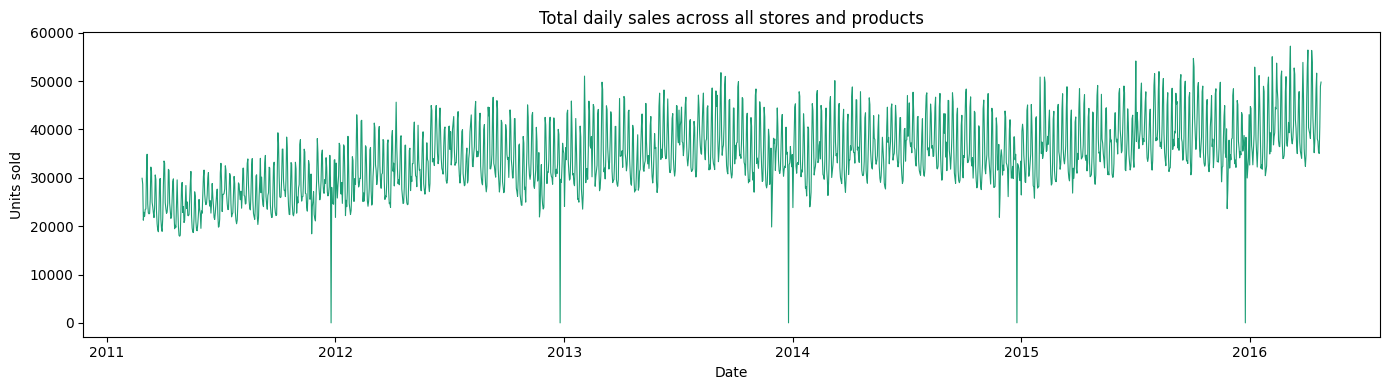

In [8]:
#Plotting total daily sales across all products and stores over the five year period
#Shows overall growth trends, seasonal patterns, and anomalies in sales
daily_sales = (df
    .groupBy("date")
    .agg(sum("sales").alias("total_sales"))
    .orderBy("date")
    .toPandas()
)

daily_sales["date"] = pd.to_datetime(daily_sales["date"])

plt.figure(figsize=(14, 4))
plt.plot(daily_sales["date"], daily_sales["total_sales"],
         linewidth=0.8, color="#1D9E75")
plt.title("Total daily sales across all stores and products")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MIS584_Project/plot_sales_over_time.png", dpi=150)
plt.show()

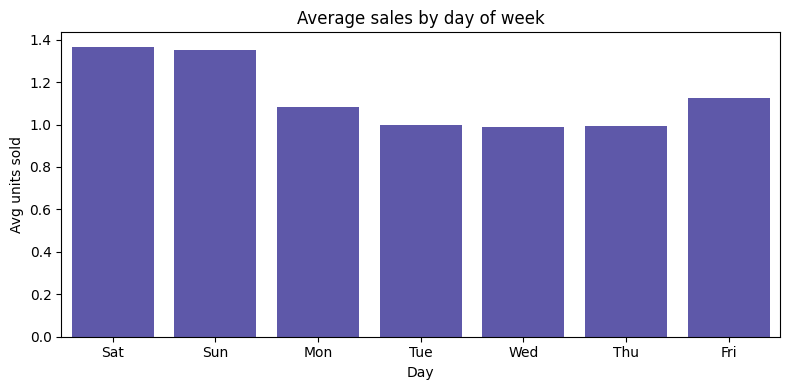

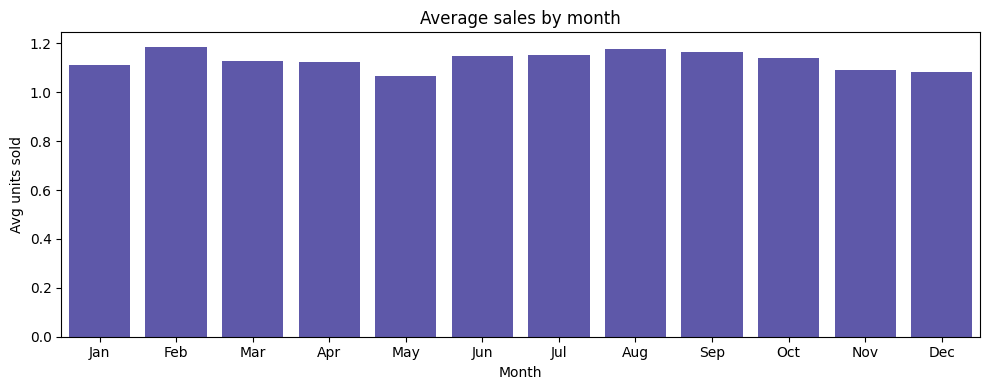

In [9]:
#Plotting average sales by day of week
#Shows which days consistently have higher or lower sales
dow_sales = (df
    .groupBy("wday")
    .agg(avg("sales").alias("avg_sales"))
    .orderBy("wday")
    .toPandas()
)

day_labels = ["Sat", "Sun", "Mon", "Tue", "Wed", "Thu", "Fri"]
dow_sales["day_name"] = dow_sales["wday"].apply(
    lambda x: day_labels[x-1] if x <= 7 else str(x))

plt.figure(figsize=(8, 4))
sns.barplot(data=dow_sales, x="day_name", y="avg_sales", color="#534AB7")
plt.title("Average sales by day of week")
plt.xlabel("Day")
plt.ylabel("Avg units sold")
plt.tight_layout()
plt.savefig("plot_sales_by_dow.png", dpi=150)
plt.show()

#Plotting average sales by month
#Shows which months consistently have higher or lower sales
monthly_sales = (df
    .groupBy("month")
    .agg(avg("sales").alias("avg_sales"))
    .orderBy("month")
    .toPandas()
)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_sales["month_name"] = monthly_sales["month"].apply(
    lambda x: month_labels[x-1])

plt.figure(figsize=(10, 4))
sns.barplot(data=monthly_sales, x="month_name", y="avg_sales", color="#534AB7")
plt.title("Average sales by month")
plt.xlabel("Month")
plt.ylabel("Avg units sold")
plt.tight_layout()
plt.savefig("plot_sales_by_month.png", dpi=150)
plt.show()

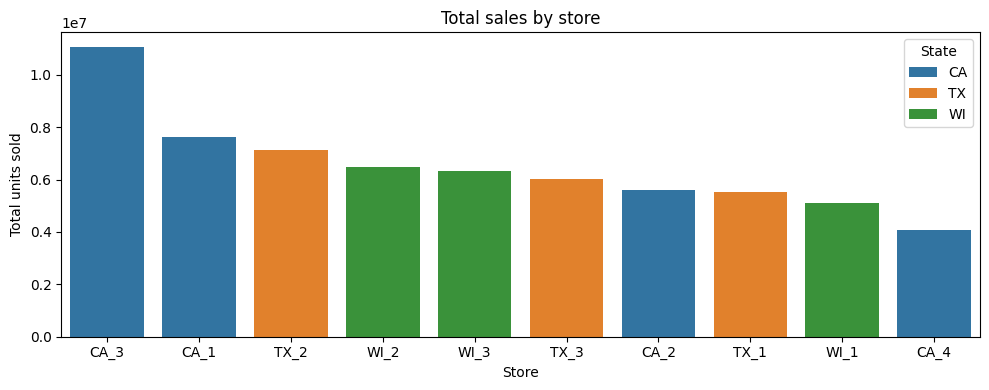

  state_id  avg_daily_sales
0       WI         1.039356
1       CA         1.233377
2       TX         1.083707


In [10]:
#Total sales per store
store_sales = (df
    .groupBy("store_id", "state_id")
    .agg(sum("sales").alias("total_sales"))
    .orderBy("total_sales", ascending=False)
    .toPandas()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=store_sales, x="store_id", y="total_sales",
            hue="state_id", dodge=False)
plt.title("Total sales by store")
plt.xlabel("Store")
plt.ylabel("Total units sold")
plt.legend(title="State")
plt.tight_layout()
plt.savefig("plot_sales_by_store.png", dpi=150)
plt.show()

#Average daily sales per state
state_sales = (df
    .groupBy("state_id")
    .agg(avg("sales").alias("avg_daily_sales"))
    .toPandas()
)

print(state_sales)

      cat_id  total_sales  avg_sales  pct_zero_days
0      FOODS   44562210.0       1.65          61.84
1  HOUSEHOLD   14352904.0       0.73          71.61
2    HOBBIES    6045612.0       0.57          77.17


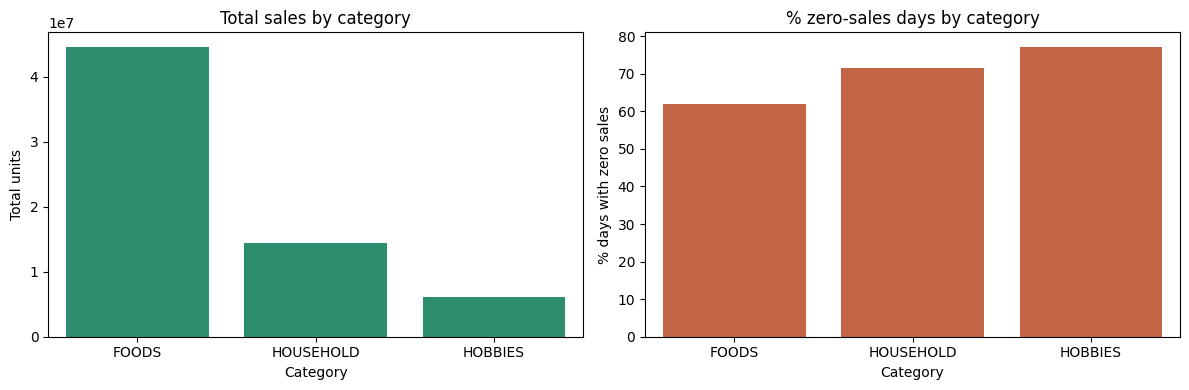

In [11]:
#Sales distribution by category
cat_sales = (df
    .groupBy("cat_id")
    .agg(
        sum("sales").alias("total_sales"),
        avg("sales").alias("avg_sales"),
        (count(when(col("sales") == 0, 1)) / count("*") * 100)
            .alias("pct_zero_days")
    )
    .orderBy("total_sales", ascending=False)
    .toPandas()
)

print(cat_sales.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=cat_sales, x="cat_id", y="total_sales",
            color="#1D9E75", ax=axes[0])
axes[0].set_title("Total sales by category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total units")

sns.barplot(data=cat_sales, x="cat_id", y="pct_zero_days",
            color="#D85A30", ax=axes[1])
axes[1].set_title("% zero-sales days by category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("% days with zero sales")

plt.tight_layout()
plt.savefig("plot_sales_by_category.png", dpi=150)
plt.show()

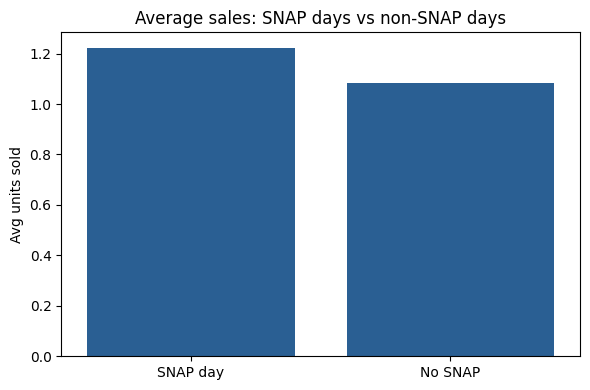

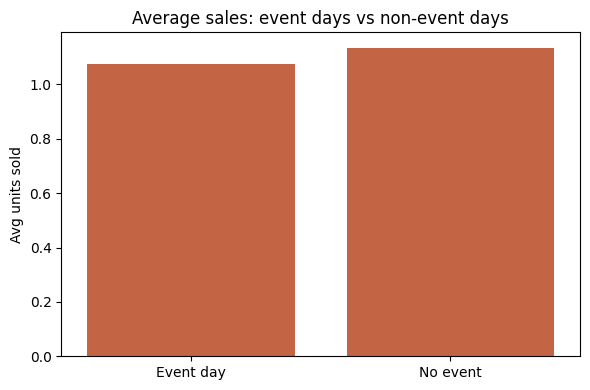

In [12]:
#SNAP days VS non-SNAP
snap_effect = (df
    .groupBy("snap_flag")
    .agg(avg("sales").alias("avg_sales"))
    .toPandas()
)
snap_effect["snap_flag"] = snap_effect["snap_flag"].map(
    {0: "No SNAP", 1: "SNAP day"})

plt.figure(figsize=(6, 4))
sns.barplot(data=snap_effect, x="snap_flag", y="avg_sales", color="#185FA5")
plt.title("Average sales: SNAP days vs non-SNAP days")
plt.xlabel("")
plt.ylabel("Avg units sold")
plt.tight_layout()
plt.savefig("plot_snap_effect.png", dpi=150)
plt.show()

#Event days vs non-event days
event_effect = (df
    .groupBy("is_event")
    .agg(avg("sales").alias("avg_sales"))
    .toPandas()
)
event_effect["is_event"] = event_effect["is_event"].map(
    {0: "No event", 1: "Event day"})

plt.figure(figsize=(6, 4))
sns.barplot(data=event_effect, x="is_event", y="avg_sales", color="#D85A30")
plt.title("Average sales: event days vs non-event days")
plt.xlabel("")
plt.ylabel("Avg units sold")
plt.tight_layout()
plt.savefig("plot_event_effect.png", dpi=150)
plt.show()

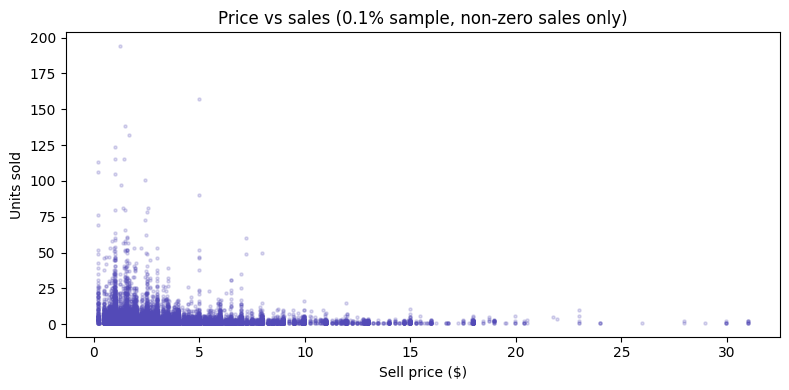

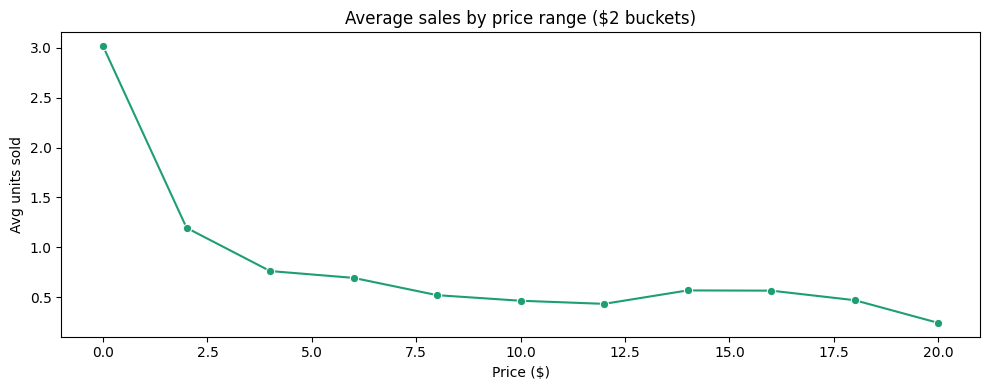

In [13]:
#Price vs demand
price_sample = (df
    .filter(col("sell_price").isNotNull())
    .filter(col("sales") > 0)
    .sample(fraction=0.001, seed=42)
    .select("sell_price", "sales")
    .toPandas()
)

plt.figure(figsize=(8, 4))
plt.scatter(price_sample["sell_price"], price_sample["sales"],
            alpha=0.2, s=5, color="#534AB7")
plt.title("Price vs sales (0.1% sample, non-zero sales only)")
plt.xlabel("Sell price ($)")
plt.ylabel("Units sold")
plt.tight_layout()
plt.savefig("plot_price_vs_sales.png", dpi=150)
plt.show()

#Average slaes by price bucket
from pyspark.sql.functions import floor

price_buckets = (df
    .filter(col("sell_price").isNotNull())
    .withColumn("price_bucket",
                (floor(col("sell_price") / 2) * 2).cast("int"))
    .groupBy("price_bucket")
    .agg(avg("sales").alias("avg_sales"))
    .orderBy("price_bucket")
    .filter(col("price_bucket") <= 20)
    .toPandas()
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=price_buckets, x="price_bucket", y="avg_sales",
             color="#1D9E75", marker="o")
plt.title("Average sales by price range ($2 buckets)")
plt.xlabel("Price ($)")
plt.ylabel("Avg units sold")
plt.tight_layout()
plt.savefig("plot_price_buckets.png", dpi=150)
plt.show()

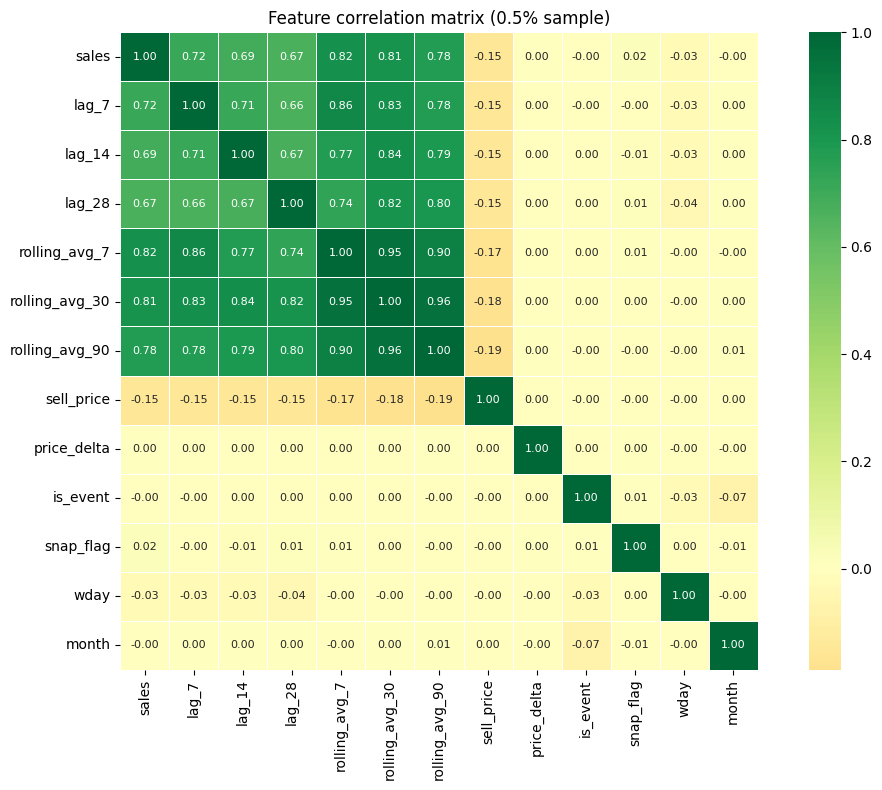

In [14]:
#Feature correlation heatmap
feature_cols = ["sales", "lag_7", "lag_14", "lag_28",
                "rolling_avg_7", "rolling_avg_30", "rolling_avg_90",
                "sell_price", "price_delta", "is_event",
                "snap_flag", "wday", "month"]

corr_sample = (df
    .select(feature_cols)
    .dropna()
    .sample(fraction=0.005, seed=42)
    .toPandas()
)

plt.figure(figsize=(11, 8))
corr_matrix = corr_sample.corr()
mask = corr_matrix.abs() < 0.02
sns.heatmap(corr_matrix,
            annot=True, fmt=".2f",
            cmap="RdYlGn", center=0,
            linewidths=0.5, square=True,
            annot_kws={"size": 8})
plt.title("Feature correlation matrix (0.5% sample)")
plt.tight_layout()
plt.savefig("plot_correlation_heatmap.png", dpi=150)
plt.show()

In [15]:
#Save plots to Google Drive
import shutil, os
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/MIS584_Project/EDA_plots'
os.makedirs(save_dir, exist_ok=True)

plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
for f in plot_files:
    shutil.copy(f, os.path.join(save_dir, f))
    print(f"Saved: {f}")

print(f"\nAll {len(plot_files)} plots saved to Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: plot_sales_by_store.png
Saved: plot_correlation_heatmap.png
Saved: plot_price_buckets.png
Saved: plot_sales_by_category.png
Saved: plot_event_effect.png
Saved: plot_sales_by_month.png
Saved: plot_snap_effect.png
Saved: plot_price_vs_sales.png
Saved: plot_sales_by_dow.png

All 9 plots saved to Drive.
